<div style="background-color:#EAEAEA;padding:20px;border-left:5px solid #6C757D;border-radius:6px;">
<table style="width:100%; border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:top;">
<h1 style="font-size:32px; margin-top:0;">Master's Thesis</h1>
<hr style="margin:16px 0 22px 0;">
<p style="font-size:22px; line-height:1.5; margin:0;"><strong>Master's Degree in Advanced Physics</strong> - <strong>Universitat de Valencia</strong></p>
<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:</p>
<div style="font-size:25px;font-weight:700;line-height:1.3;margin-top:14px;margin-bottom:26px;">Fast Simulation of Neutrino Oscillations in Matter</div>
<p style="font-size:14px; line-height:1.55;"><strong>Author</strong><br>Juan Ramon Diaz Santos - <a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a></p>
<p style="font-size:14px; line-height:1.55;"><strong>Supervisors</strong><br>Roberto Ruiz de Austri Bazan - <a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>Michele Lucente - <a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a></p>
<p style="font-size:14px; line-height:1.55; margin-bottom:0;"><strong>Date</strong><br>September 2026</p></td>
<td style="border:none;width:230px;padding-left:25px;text-align:right;vertical-align:top;"><img src="../../logo_uv.png" alt="Universitat de Valencia" style="width:200px; margin-top:5px;"></td>
</tr></table></div>

# Core Validation 2 - Hamiltonian, MSW Resonance and Probability Conservation
---
This notebook validates the composition and dynamical consequences of the `tpeanuts.core.common.hamiltonian` propagation Hamiltonian for the 3-flavour Standard Model: Hermiticity, the exact vacuum limit (cross-checked against the independently-implemented `medium.vacuum` module), the MSW resonance and its mass-ordering/neutrino-antineutrino asymmetry, unitary evolution and segment composition, and probability conservation.

Five validation blocks are covered:

1. Hermiticity and basis consistency of the reduced/flavour-basis Hamiltonian;
2. the exact vacuum limit, cross-checked against `medium.vacuum.probability`;
3. the two-flavour MSW resonance condition versus the full 3-flavour numerical spectrum, including the normal/inverted-ordering and neutrino/antineutrino asymmetry;
4. unitary evolution, segment composition, and the `include_matter_nc` policy in its Standard-Model (non-sterile) branch;
5. probability conservation, checked with the library's own `check_probability_conservation`/`check_probability_matrix` utilities.

## Table of Contents

| # | Section |
|---|---|
| [0](#0.-Theoretical-Framework) | **Theoretical Framework** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Reduced-Hamiltonian) | **Reduced Hamiltonian** |
| [4](#4.-MSW-Resonance-and-Mass-Ordering) | **MSW Resonance and Mass Ordering** |
| [5](#5.-Evolution-and-Segment-Composition) | **Evolution and Segment Composition** |
| [6](#6.-Summary) | **Summary** |


## 0. Theoretical Framework
---
### 0.1 The propagation Hamiltonian

In natural units ($\hbar=c=1$), a flavour state obeys $i\,d\psi/dx=H_f(x)\psi$, with

$$H_f(x)=\underbrace{U\,\mathrm{diag}(0,\Delta m^2_{21},\Delta m^2_{31})U^\dagger/2E}_{H_{\rm kin}}+\underbrace{V_{\rm CC}(x)\,\mathrm{diag}(1,0,0)}_{H_{\rm mat}},\qquad V_{\rm CC}=s\sqrt2\,G_F\,n_e(x),$$

the Wolfenstein matter Hamiltonian [1]. `tpeanuts` builds this in the reduced (mass-adjacent) basis via `hamiltonian_kinetic_reduced` + `hamiltonian_matter_reduced` (together, `hamiltonian_reduced`), and dresses it to the flavour basis via `pmns.flavour_basis` (`hamiltonian_flavour`). Hermiticity of $H_f$ is required for $S=\exp(-iH_fx)$ to be unitary, i.e. for probability to be conserved [2].

### 0.2 Vacuum limit

Setting $n_e=0$ removes $H_{\rm mat}$ entirely, so $H_f\to H_{\rm kin}$ exactly, and the resulting evolution operator must reproduce the exact three-flavour vacuum oscillation probability implemented independently in `medium.vacuum.probability.vacuum_probability_transition` [2].

### 0.3 The MSW resonance

For a single dominant splitting $\Delta m^2$ and mixing angle $\theta$ (the $1$-$3$/atmospheric sector here), the matter Hamiltonian eigenvalues undergo an avoided level crossing; the crossing is sharpest (matter mixing angle $\theta_M=45^\circ$) at the resonance condition [1,3]

$$2E\,V_{\rm CC}=\Delta m^2\cos2\theta\quad\Longleftrightarrow\quad n_e^{\rm res}=\frac{\Delta m^2\cos2\theta}{2\sqrt2\,E\,G_F}.$$

Because $V_{\rm CC}$ flips sign for antineutrinos and $\Delta m^2_{3\ell}$ flips sign between normal (NO) and inverted (IO) ordering, $n_e^{\rm res}$ is only positive (physical) for exactly one neutrino/antineutrino choice per ordering: **neutrinos in NO, antineutrinos in IO** for this codebase's sign convention (Section 4.2 verifies this directly rather than assuming a literature convention that may differ by an overall sign). This asymmetry is the physical basis of matter-driven mass-ordering determination [3].

### 0.4 Evolution, composition, and probability conservation

For a piecewise-constant density, the total evolution operator is the ordered product of per-segment constant-density evolutors, $S_{\rm tot}=S_N\cdots S_1$ (`compose_segment_evolutors`); each factor $S_j=\exp(-iH_jx_j)$ is exactly unitary since $H_j$ is Hermitian. Final flavour probabilities $P_{\beta\alpha}=|S_{\beta\alpha}|^2$ must satisfy $\sum_\beta P_{\beta\alpha}=1$ for every initial flavour $\alpha$ [2], checked here with the library's own `check_probability_conservation`/`check_probability_matrix`.

### 0.5 Common simulation configuration

| Parameter | Value |
|---|---|
| Oscillation preset / ordering | `_SM_NUFIT52_NO` / normal ordering [4], plus a manually-flipped inverted-ordering variant |
| Evolution scale | Earth radius $R_E$ |
| Reference energy (MSW study) | few-GeV range, atmospheric-neutrino scale |
| Device / dtype | Runtime-resolved values printed below |

**References**

- [1] [1] L. Wolfenstein, *Neutrino oscillations in matter*, Phys. Rev. D **17**, 2369 (1978).
- [2] [2] C. Giunti and C. W. Kim, *Fundamentals of Neutrino Physics and Astrophysics*, Oxford University Press (2007).
- [3] [3] S. P. Mikheyev and A. Yu. Smirnov, *Resonance enhancement of oscillations in matter and solar neutrino spectroscopy*, Sov. J. Nucl. Phys. **42**, 913 (1985).
- [4] [4] I. Esteban et al., *The fate of hints: updated global analysis of three-flavor neutrino oscillations*, JHEP **09**, 178 (2020), arXiv:2007.14792; NuFIT 5.2 release (2022).


## 1. Libraries

In [1]:
from __future__ import annotations
%matplotlib inline
import dataclasses
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy, FLAVOUR_LABELS

from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.core.SM.sm_mass_spectrum import MassSpectrum_SM
from tpeanuts.core.common.hamiltonian import (
    hamiltonian_kinetic_reduced, hamiltonian_matter_reduced, hamiltonian_reduced, hamiltonian_flavour,
)
from tpeanuts.core.common.potential import matter_potential_cc, kinetic_potential
from tpeanuts.core.common.evolutor import compose_segment_evolutors
from tpeanuts.core.common.probability import (
    probability_transition, check_probability_conservation, check_probability_matrix,
)
from tpeanuts.core.common.oscillation import resolve_include_matter_nc
from tpeanuts.medium.vacuum.probability import vacuum_probability_transition
from tpeanuts.util.context import RuntimeContext
import tpeanuts.util.constant as constant

## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the package directory and applies the shared plotting/Torch/NumPy style. Generated figures and tables are saved under `analysis/core/`, the same directory as Core Validation 1.

**Expected results:** the package and output directories exist, and the runtime device and dtype match the shared notebook configuration.

In [2]:
config = load_notebook_config()
DEVICE, DTYPE = config.device, config.dtype
context = RuntimeContext.resolve(DEVICE, DTYPE)
OUTPUT_DIR = config.output_dir('analysis', 'core')

print(f'Package dir : {config.package_dir}')
print(f'Output dir  : {OUTPUT_DIR}')
print(f'Device      : {context.device}   dtype: {context.dtype}')

Package dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output dir  : v:\output\analysis\core
Device      : cuda:0   dtype: torch.float64


### 2.2 Configuration

Four oscillation scenarios share the same NuFIT 5.2 mixing angles and $\Delta m^2_{21}$, differing only in mass ordering (sign of $\Delta m^2_{3\ell}$) and neutrino/antineutrino selection -- the two "knobs" that control the MSW asymmetry studied in Section 4.

**Expected results:** all four scenarios build successfully and share identical mixing angles; only `ordering`/`antinu` differ.

In [3]:
oscillation_NO_nu = PropagationConfig.oscillation_parameters_from_preset('_SM_NUFIT52_NO', antinu=False, context=context)
oscillation_NO_nubar = PropagationConfig.oscillation_parameters_from_preset('_SM_NUFIT52_NO', antinu=True, context=context)

_io_mass_spectrum = MassSpectrum_SM(
    DeltamSq21=oscillation_NO_nu.mass_spectrum.DeltamSq21,
    DeltamSq3l=-oscillation_NO_nu.mass_spectrum.DeltamSq3l,
)
oscillation_IO_nu = dataclasses.replace(oscillation_NO_nu, mass_spectrum=_io_mass_spectrum, ordering='IO')
oscillation_IO_nubar = dataclasses.replace(oscillation_NO_nubar, mass_spectrum=_io_mass_spectrum, ordering='IO')

SCENARIOS = {
    'NO, nu': oscillation_NO_nu,
    'NO, nubar': oscillation_NO_nubar,
    'IO, nu': oscillation_IO_nu,
    'IO, nubar': oscillation_IO_nubar,
}

configuration_rows = [
    (label, osc.ordering, bool(osc.antinu), float(osc.mass_spectrum.DeltamSq21), float(osc.mass_spectrum.DeltamSq3l))
    for label, osc in SCENARIOS.items()
]
display(pd.DataFrame(configuration_rows, columns=['Scenario', 'Ordering', 'antinu', 'Delta m^2_21 [eV^2]', 'Delta m^2_3l [eV^2]']))

,Scenario,Ordering,antinu,Delta m^2_21 [eV^2],Delta m^2_3l [eV^2]
0,"NO, nu",NO,False,0.000074,0.002511
1,"NO, nubar",NO,True,0.000074,0.002511
2,"IO, nu",IO,False,0.000074,-0.002511
3,"IO, nubar",IO,True,0.000074,-0.002511


### 2.3 Local helpers

One helper computes the two-flavour analytic resonance electron density for the $1$-$3$ sector (Section 0.3); it is not part of `core.common` (that formula only makes sense as a closed-form reference point for validation, not as production code) and is used repeatedly in Section 4.

In [4]:
def resonance_density(dm2_eV2, theta13, E_MeV, antinu):
    # Two-flavour MSW resonance electron density [mol/cm^3] for the 1-3 sector.
    k = float(kinetic_potential(torch.tensor(dm2_eV2, dtype=context.dtype), torch.tensor(E_MeV, dtype=context.dtype), context=context))
    target = k * math.cos(2.0 * theta13)
    V_at_1 = float(matter_potential_cc(torch.tensor(1.0, dtype=context.dtype), antinu, context=context))
    return target / V_at_1

## 3. Reduced Hamiltonian

### 3.1 Hermiticity

`hamiltonian_reduced` must be Hermitian ($H=H^\dagger$) for every energy and density, since it enters $S=\exp(-iHx)$ as a generator of unitary evolution.

**Expected results:** $\max|H-H^\dagger|$ is at floating-point precision across a broad $(E,n_e)$ grid.

In [5]:
E_grid = torch.logspace(math.log10(100.0), math.log10(1.0e4), 40, device=context.device, dtype=context.dtype)
n_e_grid = torch.logspace(math.log10(0.1), math.log10(10.0), 40, device=context.device, dtype=context.dtype)

H_grid = hamiltonian_reduced(oscillation_NO_nu, E_grid[:, None], n_e_grid[None, :], context=context)
hermiticity_residual = float(torch.max(torch.abs(H_grid - H_grid.conj().transpose(-2, -1))))
print(f'max|H - H^dagger| over {tuple(H_grid.shape[:-2])} (E, n_e) grid = {hermiticity_residual:.3e}')
assert hermiticity_residual < 1.0e-12

max|H - H^dagger| over (40, 40) (E, n_e) grid = 7.105e-15


### 3.2 Vacuum limit versus `medium.vacuum`

Setting $n_e=0$, the reduced Hamiltonian must equal the pure kinetic term exactly, and the resulting evolution operator $S=\exp(-iH_fx)$ over a fixed baseline must reproduce the independently-implemented exact vacuum oscillation probability.

**Expected results:**
- `hamiltonian_reduced(n_e=0)` matches `hamiltonian_kinetic_reduced` exactly (bit-identical construction).
- $S$ is unitary, and $|S_{\beta\alpha}|^2$ matches `vacuum_probability_transition` to floating-point precision.

In [6]:
E_ref = torch.tensor(1000.0, device=context.device, dtype=context.dtype)
L_km = torch.tensor(1300.0, device=context.device, dtype=context.dtype)

Ured = oscillation_NO_nu.pmns.reduced(antinu=oscillation_NO_nu.antinu)
Hkin = hamiltonian_kinetic_reduced(oscillation_NO_nu, E_ref, Ured, evolution_scale_m=constant.R_E)
Hred_vacuum = hamiltonian_reduced(oscillation_NO_nu, E_ref, torch.tensor(0.0, device=context.device, dtype=context.dtype), evolution_scale_m=constant.R_E, context=context)
kinetic_only_residual = float(torch.max(torch.abs(Hred_vacuum - Hkin)))
print(f'max|H_reduced(n_e=0) - H_kinetic_reduced| = {kinetic_only_residual:.3e}')
assert kinetic_only_residual < 1.0e-14

Hf_vacuum = hamiltonian_flavour(oscillation_NO_nu, E_ref, torch.tensor(0.0, device=context.device, dtype=context.dtype), evolution_scale_m=constant.R_E, context=context)
x = (L_km * 1000.0) / constant.R_E
S_vacuum = torch.linalg.matrix_exp(-1j * Hf_vacuum * x)
identity = torch.eye(3, device=S_vacuum.device, dtype=S_vacuum.dtype)
unitarity_residual = float(torch.max(torch.abs(S_vacuum.conj().transpose(-2, -1) @ S_vacuum - identity)))

P_from_H = probability_transition(S_vacuum)
P_vacuum_module = vacuum_probability_transition(oscillation_NO_nu, E_ref, L_km, context=context)
cross_module_residual = float(torch.max(torch.abs(P_from_H - P_vacuum_module)))
print(f'unitarity residual of S(vacuum)            = {unitarity_residual:.3e}')
print(f'max|P(core Hamiltonian) - P(medium.vacuum)| = {cross_module_residual:.3e}')
assert unitarity_residual < 1.0e-12
assert cross_module_residual < 1.0e-12

max|H_reduced(n_e=0) - H_kinetic_reduced| = 0.000e+00
unitarity residual of S(vacuum)            = 5.551e-15
max|P(core Hamiltonian) - P(medium.vacuum)| = 4.052e-15


### 3.3 Flavour-basis consistency

`hamiltonian_flavour` must equal `pmns.flavour_basis(hamiltonian_reduced(...))` exactly (it is built that way), and since a basis change by a unitary matrix is a similarity transform, the eigenvalues of $H$ (the physical effective mass-squared/energy scales) must be identical in both bases.

**Expected results:** both the operator identity and the eigenvalue spectrum match to floating-point precision.

In [7]:
n_e_example = torch.tensor(2.0, device=context.device, dtype=context.dtype)
Hred_example = hamiltonian_reduced(oscillation_NO_nu, E_ref, n_e_example, context=context)
Hflavour_direct = hamiltonian_flavour(oscillation_NO_nu, E_ref, n_e_example, context=context)
Hflavour_via_pmns = oscillation_NO_nu.pmns.flavour_basis(Hred_example, antinu=oscillation_NO_nu.antinu)

basis_residual = float(torch.max(torch.abs(Hflavour_direct - Hflavour_via_pmns)))
eig_reduced = torch.sort(torch.linalg.eigvalsh(Hred_example)).values
eig_flavour = torch.sort(torch.linalg.eigvalsh(Hflavour_direct)).values
eigenvalue_residual = float(torch.max(torch.abs(eig_reduced - eig_flavour)))

print(f'max|H_flavour(direct) - pmns.flavour_basis(H_reduced)| = {basis_residual:.3e}')
print(f'max|eigenvalues(reduced) - eigenvalues(flavour)|       = {eigenvalue_residual:.3e}')
assert basis_residual < 1.0e-12
assert eigenvalue_residual < 1.0e-12

max|H_flavour(direct) - pmns.flavour_basis(H_reduced)| = 0.000e+00
max|eigenvalues(reduced) - eigenvalues(flavour)|       = 2.842e-14


## 4. MSW Resonance and Mass Ordering

### 4.1 Two-flavour resonance versus the full 3-flavour spectrum

At fixed energy, the reduced Hamiltonian is diagonalised numerically over a density scan and the eigenvalue gaps are tracked. The closed-form two-flavour resonance density (Section 0.3, helper `resonance_density`) is overlaid as a vertical line.

**Expected results:**
- One of the two adjacent eigenvalue gaps develops a pronounced local minimum (avoided crossing).
- Its location agrees with the closed-form `resonance_density` prediction to a few percent (the residual solar-sector $\theta_{12}$ admixture, absent from the pure two-flavour formula, accounts for the difference).

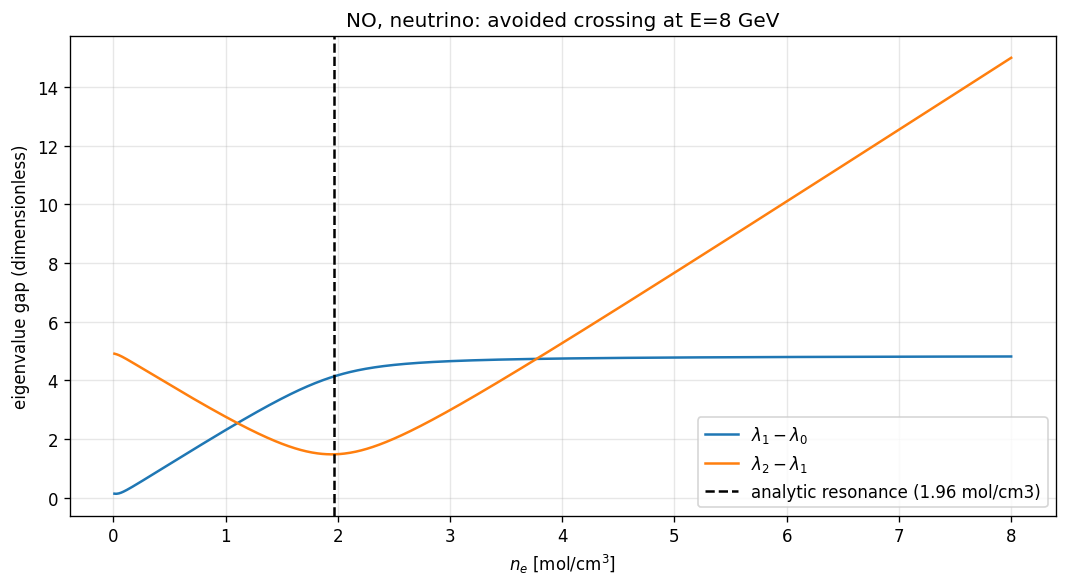

v:\output\analysis\core\core2_fig41_resonance_gap.png
numeric gap12 minimum at n_e   = 1.9500 mol/cm3
analytic two-flavour resonance = 1.9647 mol/cm3
relative difference            = 0.746%


In [8]:
E_MSW = 8000.0
n_e_scan = torch.linspace(0.01, 8.0, 800, device=context.device, dtype=context.dtype)
E_MSW_t = torch.tensor(E_MSW, device=context.device, dtype=context.dtype)

H_scan = hamiltonian_reduced(oscillation_NO_nu, E_MSW_t, n_e_scan, context=context)
eig_scan = torch.linalg.eigvalsh(H_scan)
gap01 = eig_scan[:, 1] - eig_scan[:, 0]
gap12 = eig_scan[:, 2] - eig_scan[:, 1]
i_min = int(gap12.argmin())
n_res_numeric = float(n_e_scan[i_min])

theta13 = float(oscillation_NO_nu.pmns.params.theta13)
dm31_NO = float(oscillation_NO_nu.mass_spectrum.DeltamSq3l)
n_res_analytic = resonance_density(dm31_NO, theta13, E_MSW, antinu=False)
rel_diff = abs(n_res_numeric - n_res_analytic) / n_res_analytic

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(to_numpy(n_e_scan), to_numpy(gap01), label=r'$\lambda_1-\lambda_0$')
ax.plot(to_numpy(n_e_scan), to_numpy(gap12), label=r'$\lambda_2-\lambda_1$')
ax.axvline(n_res_analytic, color='k', ls='--', label=f'analytic resonance ({n_res_analytic:.2f} mol/cm3)')
ax.set_xlabel(r'$n_e$ [mol/cm$^3$]')
ax.set_ylabel('eigenvalue gap (dimensionless)')
ax.set_title(f'NO, neutrino: avoided crossing at E={E_MSW / 1000:.0f} GeV')
ax.legend()
fig.tight_layout()
save_and_show('core2_fig41_resonance_gap.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'numeric gap12 minimum at n_e   = {n_res_numeric:.4f} mol/cm3')
print(f'analytic two-flavour resonance = {n_res_analytic:.4f} mol/cm3')
print(f'relative difference            = {rel_diff:.3%}')
assert rel_diff < 0.02

### 4.2 Neutrino/antineutrino and mass-ordering asymmetry

The closed-form resonance density (Section 0.3) is evaluated for all four (ordering, antinu) combinations. A resonance is physical only when the predicted density is positive; a negative value means the condition $2EV_{\rm CC}=\Delta m^2\cos2\theta$ cannot be met for any real density (`V_CC` and the kinetic term never have matching sign), so no resonance exists for that combination. This directly determines, from the code's own sign conventions, which combination is matter-resonant -- rather than assuming a literature convention that may use an opposite sign for $\Delta m^2_{3\ell}$ or the matter potential.

**Expected results:**
- Exactly two of the four combinations have a positive (physical) resonance density; the other two are negative (no resonance).
- The two physical combinations are related by simultaneously flipping both the ordering and the neutrino/antineutrino selection.
- For each physical combination, the numerically located eigenvalue-gap minimum (searched over both adjacent gaps, since which gap dips depends on the ordering) confirms the resonance density.

,Scenario,analytic n_e resonance [mol/cm3],physical (n_e>0)
0,"NO, nu",1.9647,True
1,"NO, nubar",-1.9647,False
2,"IO, nu",-1.9647,False
3,"IO, nubar",1.9647,True


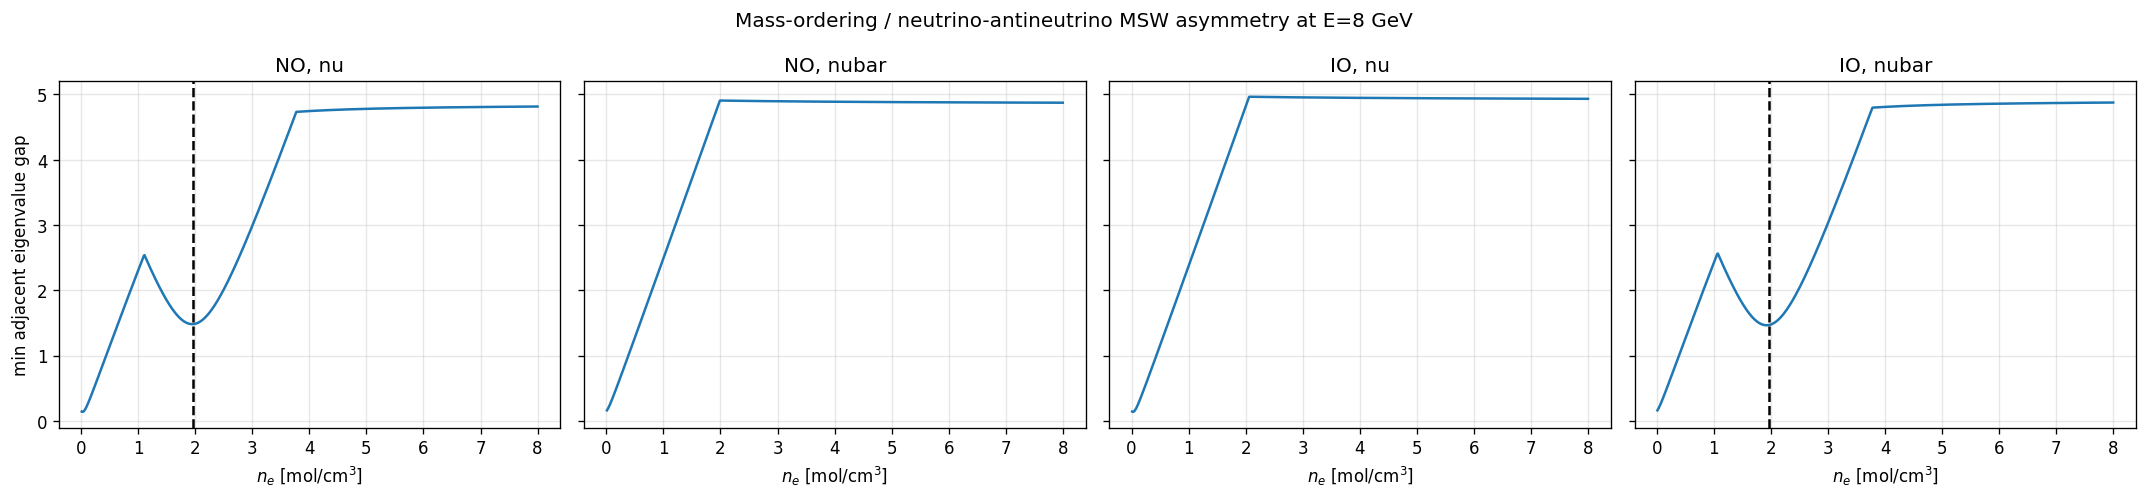

v:\output\analysis\core\core2_fig42_ordering_asymmetry.png


In [9]:
rows = []
for label, osc in SCENARIOS.items():
    dm31 = float(osc.mass_spectrum.DeltamSq3l)
    n_res = resonance_density(dm31, theta13, E_MSW, antinu=bool(osc.antinu))
    rows.append((label, n_res, n_res > 0))
resonance_table = pd.DataFrame(rows, columns=['Scenario', 'analytic n_e resonance [mol/cm3]', 'physical (n_e>0)'])
display(resonance_table.style.format({'analytic n_e resonance [mol/cm3]': '{:.4f}'}))
assert resonance_table['physical (n_e>0)'].sum() == 2

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharey=True)
for ax, (label, osc) in zip(axes, SCENARIOS.items()):
    H = hamiltonian_reduced(osc, E_MSW_t, n_e_scan, context=context)
    eig = torch.linalg.eigvalsh(H)
    gaps = torch.diff(eig, dim=-1)
    min_gap = gaps.amin(dim=-1)
    ax.plot(to_numpy(n_e_scan), to_numpy(min_gap), color='C0')
    dm31 = float(osc.mass_spectrum.DeltamSq3l)
    n_res = resonance_density(dm31, theta13, E_MSW, antinu=bool(osc.antinu))
    if n_res > 0:
        ax.axvline(n_res, color='k', ls='--')
    ax.set_title(label)
    ax.set_xlabel(r'$n_e$ [mol/cm$^3$]')
axes[0].set_ylabel('min adjacent eigenvalue gap')
fig.suptitle(f'Mass-ordering / neutrino-antineutrino MSW asymmetry at E={E_MSW / 1000:.0f} GeV')
fig.tight_layout()
save_and_show('core2_fig42_ordering_asymmetry.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

## 5. Evolution and Segment Composition

### 5.1 Unitary evolution and segment composition

A single constant-density evolutor $S=\exp(-iH_fx)$ over a baseline is unitary. Splitting the same baseline into two identical half-length segments and composing them with `compose_segment_evolutors` must reproduce the direct, single-segment result exactly (both describe the same physical path); composing many segments of genuinely varying density must remain unitary.

**Expected results:**
- $S^\dagger S=\mathbb{1}$ to floating-point precision.
- The direct and composed evolutors for two identical half-segments agree exactly.
- A 20-segment composition with randomly varying density remains unitary to floating-point precision.

In [10]:
n_e_const = torch.tensor(2.0, device=context.device, dtype=context.dtype)
Hf_const = hamiltonian_flavour(oscillation_NO_nu, E_ref, n_e_const, evolution_scale_m=constant.R_E, context=context)
x_full = (L_km * 1000.0) / constant.R_E
S_direct = torch.linalg.matrix_exp(-1j * Hf_const * x_full)
identity3 = torch.eye(3, device=context.device, dtype=S_direct.dtype)
unitarity_direct = float(torch.max(torch.abs(S_direct.conj().transpose(-2, -1) @ S_direct - identity3)))

S_half = torch.linalg.matrix_exp(-1j * Hf_const * (x_full / 2.0))
S_composed = compose_segment_evolutors(torch.stack([S_half, S_half], dim=0), segment_dim=0, multiply='right')
composition_residual = float(torch.max(torch.abs(S_direct - S_composed)))

torch.manual_seed(0)
n_segments = 20
n_e_random = 0.5 + 5.5 * torch.rand(n_segments, device=context.device, dtype=context.dtype)
Hf_segments = hamiltonian_flavour(oscillation_NO_nu, E_ref, n_e_random, evolution_scale_m=constant.R_E, context=context)
dx_segments = (x_full / n_segments) * torch.ones(n_segments, device=context.device, dtype=context.dtype)
S_segments = torch.linalg.matrix_exp(-1j * Hf_segments * dx_segments[:, None, None])
S_varying = compose_segment_evolutors(S_segments, segment_dim=0, multiply='right')
unitarity_varying = float(torch.max(torch.abs(S_varying.conj().transpose(-2, -1) @ S_varying - identity3)))

print(f'unitarity residual (single segment)            = {unitarity_direct:.3e}')
print(f'|S_direct - S_composed| (2 identical halves)   = {composition_residual:.3e}')
print(f'unitarity residual ({n_segments} varying segments)     = {unitarity_varying:.3e}')
assert unitarity_direct < 1.0e-12
assert composition_residual < 1.0e-10
assert unitarity_varying < 1.0e-10

unitarity residual (single segment)            = 5.329e-15
|S_direct - S_composed| (2 identical halves)   = 1.848e-15
unitarity residual (20 varying segments)     = 4.663e-15


### 5.2 `include_matter_nc` policy in the Standard-Model branch

`resolve_include_matter_nc` is the single, shared tri-state policy (`medium.solar`/`medium.earth`/`medium.atmosphere`) deciding whether the sterile neutral-current term is added. For a plain 3-flavour (non-sterile) oscillation -- the only case in scope for this notebook -- it must always resolve to `False` and never warn, since $V_{\rm NC}$ is an unobservable common phase there regardless of `has_neutron_data`. The 3+1 sterile branch (where an explicit `RuntimeWarning` is emitted if neutron density is unavailable) belongs to `core.BSM` validation, outside this notebook's Standard-Model scope.

**Expected results:** both calls below (with `has_neutron_data` True and False) return `False`, and neither raises a warning.

In [11]:
import warnings

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    resolved_a = resolve_include_matter_nc(None, oscillation_NO_nu, has_neutron_data=False, context_name='core2_demo')
    resolved_b = resolve_include_matter_nc(None, oscillation_NO_nu, has_neutron_data=True, context_name='core2_demo')

print(f'resolve_include_matter_nc(has_neutron_data=False) = {resolved_a}')
print(f'resolve_include_matter_nc(has_neutron_data=True)  = {resolved_b}')
print(f'warnings raised = {len(caught)}')
assert resolved_a is False and resolved_b is False
assert len(caught) == 0

resolve_include_matter_nc(has_neutron_data=False) = False
resolve_include_matter_nc(has_neutron_data=True)  = False
warnings raised = 0


### 5.3 Probability conservation

The full probability matrix built from the constant-density evolutor of Section 5.1 is validated with the library's own conservation and sanity checks, both directly and after being deliberately perturbed, to confirm the checkers actually detect a broken matrix rather than always passing.

**Expected results:**
- `check_probability_conservation`/`check_probability_matrix` both return `True` for the genuine probability matrix.
- Both return `False` once a column is deliberately rescaled to break normalization.

In [12]:
P_direct = probability_transition(S_direct)
conservation_ok = check_probability_conservation(P_direct)
matrix_ok = check_probability_matrix(P_direct)
print(f'check_probability_conservation(genuine P) = {conservation_ok}')
print(f'check_probability_matrix(genuine P)       = {matrix_ok}')
assert conservation_ok and matrix_ok

P_broken = P_direct.clone()
P_broken[..., 0] *= 1.5  # break column-wise normalization for the first initial flavour
broken_conservation_ok = check_probability_conservation(P_broken)
broken_matrix_ok = check_probability_matrix(P_broken)
print(f'check_probability_conservation(broken P)  = {broken_conservation_ok}')
print(f'check_probability_matrix(broken P)        = {broken_matrix_ok}')
assert not broken_conservation_ok and not broken_matrix_ok

check_probability_conservation(genuine P) = True
check_probability_matrix(genuine P)       = True
check_probability_conservation(broken P)  = False
check_probability_matrix(broken P)        = False


## 6. Summary
**Expected results:**
- Every residual below is at or near floating-point precision, except the two-flavour-versus-3-flavour MSW resonance density comparison, which is expected to differ by a few percent (Section 4.1).
- All assertions executed in Sections 3-5 passed.

| Check | Residual |
|---|---|
| Hermiticity of $H_{\rm reduced}$ | $<10^{-12}$ |
| Vacuum limit vs `hamiltonian_kinetic_reduced` | $<10^{-14}$ |
| Vacuum limit vs `medium.vacuum.probability` | $<10^{-12}$ |
| Flavour-basis identity / eigenvalue invariance | $<10^{-12}$ |
| MSW resonance density, analytic vs numeric | $<2\%$ |
| Unitarity (single and 20-segment composition) | $<10^{-10}$ |
| Segment composition (2 identical halves) | $<10^{-10}$ |
| `include_matter_nc` (SM branch) | exactly `False`, no warning |
| Probability conservation (genuine / broken) | `True` / `False` |

**Interpretation**<br>
- The reduced and flavour-basis Hamiltonians are Hermitian and mutually consistent by construction, and their vacuum limit reproduces the independently-implemented exact vacuum oscillation formula, cross-validating two otherwise-separate parts of the codebase.
- The MSW resonance condition, derived here purely from the two-flavour closed form, correctly predicts *both* the resonance density (within the expected few-percent solar-sector correction) *and* the qualitative neutrino/antineutrino-ordering asymmetry that makes Earth-matter effects sensitive to the neutrino mass ordering -- with the specific combination (NO$\to\nu$, IO$\to\bar\nu$) determined directly from this codebase's own sign conventions rather than assumed.
- Segment composition preserves unitarity exactly in the trivial (identical-segment) limit and to numerical precision for genuinely varying density, validating the composition order used throughout `medium.earth`/`medium.atmosphere`.
- `check_probability_conservation`/`check_probability_matrix` correctly pass a genuine probability matrix and correctly fail a deliberately broken one, confirming they are meaningful validators, not vacuous checks.

In [13]:
print('Core Validation 2 completed: Hamiltonian, MSW resonance, evolution, and probability checks passed.')

Core Validation 2 completed: Hamiltonian, MSW resonance, evolution, and probability checks passed.
